# Import

In [ ]:
import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from xhistogram.xarray import histogram as xhist

from glob import glob
import cartopy
import cartopy.crs as ccrs
from cartopy.crs import Geodetic, PlateCarree
from time import time
import warnings
import shapely
import itertools
from itertools import chain

warnings.simplefilter("ignore")

# Set Parameters

In [ ]:
# Parameters
base_path = "/gxfs_work/geomar/smomw597/2025_Fucus"
release_depth = 0
relative_particle_speed = 1

In [ ]:
base_path = Path(base_path)
repo_path = Path(base_path, "2025_fucus-dispersal")

In [ ]:
# zarr_path = Path(base_path, "output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
zarr_path = Path(base_path, "output/Trajectories/2022/Fucus_BSH_20220101-20220625_dt60min_N453440_seed123.zarr")
zarr_path = Path(base_path, "output/Trajectories/2019/Fucus_BSH_20190101-20190625_dt60min_d0_s1_N226720_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path)
ds_trajectories.nbytes/1e9

In [ ]:
output_path = Path(base_path, "output/Trajectories")
zarr_files = sorted(output_path.glob(f"20??/Fucus_BSH_20??????-20??????_dt60min_d{release_depth}_s{relative_particle_speed}_N2*"))
print(np.array(zarr_files))
ds_trajectories = xr.concat([xr.open_zarr(s) for s in zarr_files], dim="trajectory")
ds_trajectories.nbytes/1e9

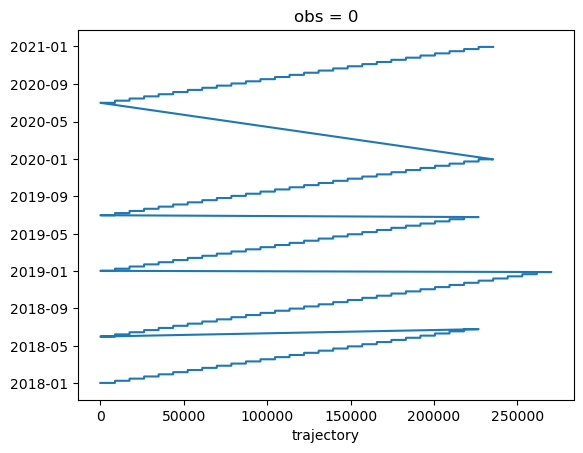

In [5]:
ds_trajectories.time.isel(obs=0).plot()

In [6]:
if len(np.unique(ds_trajectories.isel(obs=0).z.compute())) > 1:
        ds_traj = ds_trajectories.isel(obs=0).groupby("z")
        ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[0].trajectory.values)
        # ds_trajectories = ds_trajectories.sel(trajectory=ds_traj[1].trajectory.values)
else:
        ds_trajectories = ds_trajectories.drop("z")
ds_trajectories.nbytes/1e9

220.20562496

In [7]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ""
list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).astype(int)

In [ ]:
release_area_path = Path(repo_path, "data/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[(gdf_release_area.F_vesiculo != 0).values, ["geometry", "CELLCODE"]]

subbasins_path = Path(repo_path, "HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic()).rename(dict(level_2="subbasin"), axis=1)

In [9]:
subbasins_simple = gdf_subbasins_area.set_index("subbasin").geometry.buffer(0.2).buffer(-0.2).exterior
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "subbasin", "geometry"]]

In [10]:
try: ds_trajectories.lat.isel(trajectory=0).compute()
except: 
        ds_trajectories = ds_trajectories.isel(obs=slice(2112))
        print("cut")

In [ ]:
earth_radius = 6371.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon * r * degrees_to_radians
def latlon_dist_to_km(ds):
        dlat = ds.lat - ds.lat.isel(obs=0, drop=True)
        return ((dlat_to_dkm(dlat)**2 + dlon_to_dkm(ds.lat + dlat/2, ds.lon - ds.lon.isel(obs=0, drop=True))**2)**.5).rename("dist")

In [12]:
ds_trajectories = ds_trajectories.assign(
        dict(
                distance=latlon_dist_to_km(ds_trajectories),
                subbasin=("trajectory", gdf_release_area.loc[list_cell_ID].subbasin.values),
                cell_ID=list_cell_ID,
                # cell_code=("trajectory", cell_codes),
        )
)

In [ ]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

ds_trajectories = ds_trajectories.where(last_step.distance.drop("obs") > 1, drop=True)

In [20]:
lon_min, lon_max = (5,32)
lat_min, lat_max = (53,66)
extent = (lon_min, lon_max, lat_min, lat_max)
central_longitude = np.mean((lon_min, lon_max))
central_latitude = np.mean((lat_min, lat_max))
map_projection = ccrs.EckertIV(central_longitude=central_longitude)

In [15]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [16]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None, ):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

# Maps

## Heatmap

In [17]:
n_bins = 120
ds_plot_traj_count = ds_trajectories.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_0(
                ds.unstack(),
                np.linspace(lon_min, lon_max, n_bins),
                np.linspace(lat_min, lat_max, n_bins),
                dims=["trajectory"],
        )
).compute()

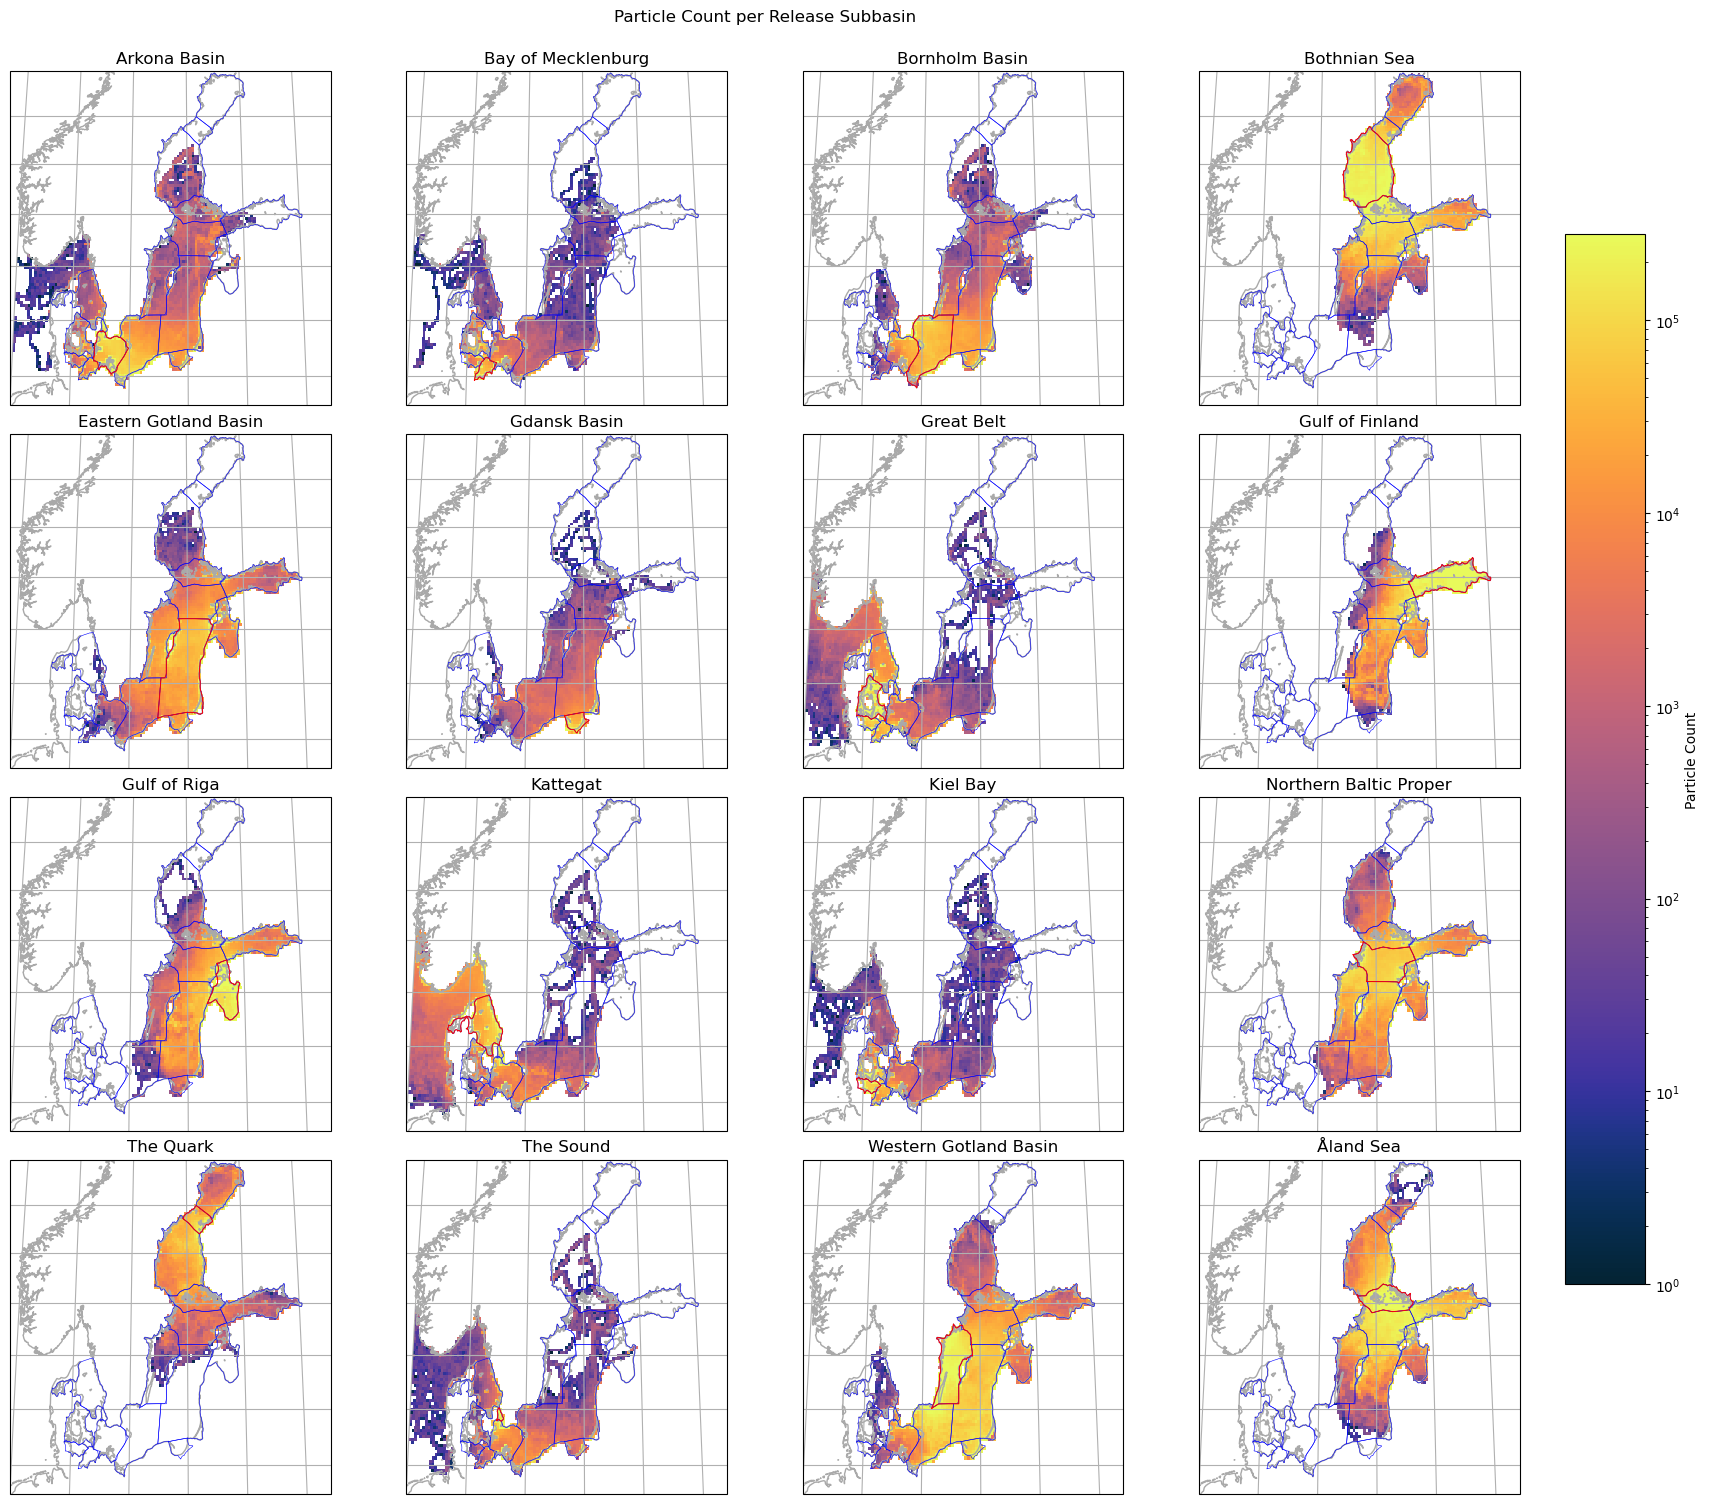

In [ ]:
ds_plot = ds_plot_traj_count.sum(dim="obs")

vmax = ds_plot.where(ds_plot.notnull() & ds_plot > 0).quantile(0.95)
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, 
        ncols=4, 
        sharex=True, 
        sharey=True, 
        subplot_kw=dict(projection=map_projection), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        color = np.where(subbasins_simple.index == basin, "r", "b")
        subbasins_simple.plot(ax=ax, transform=Geodetic(), color=color, lw=.4, zorder=10)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", 
                y="lat", 
                ax=ax, 
                cmap=cmocean.cm.thermal,
                norm=norm,
                add_colorbar=False, 
                transform=PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(extent)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

## Agemap

In [18]:
n_bins = 120
ds_plot_traj_age = ds_trajectories.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, n_bins),
                np.linspace(lat_min, lat_max, n_bins),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

In [ ]:
mpl.colors.Normalize(0,vmax)

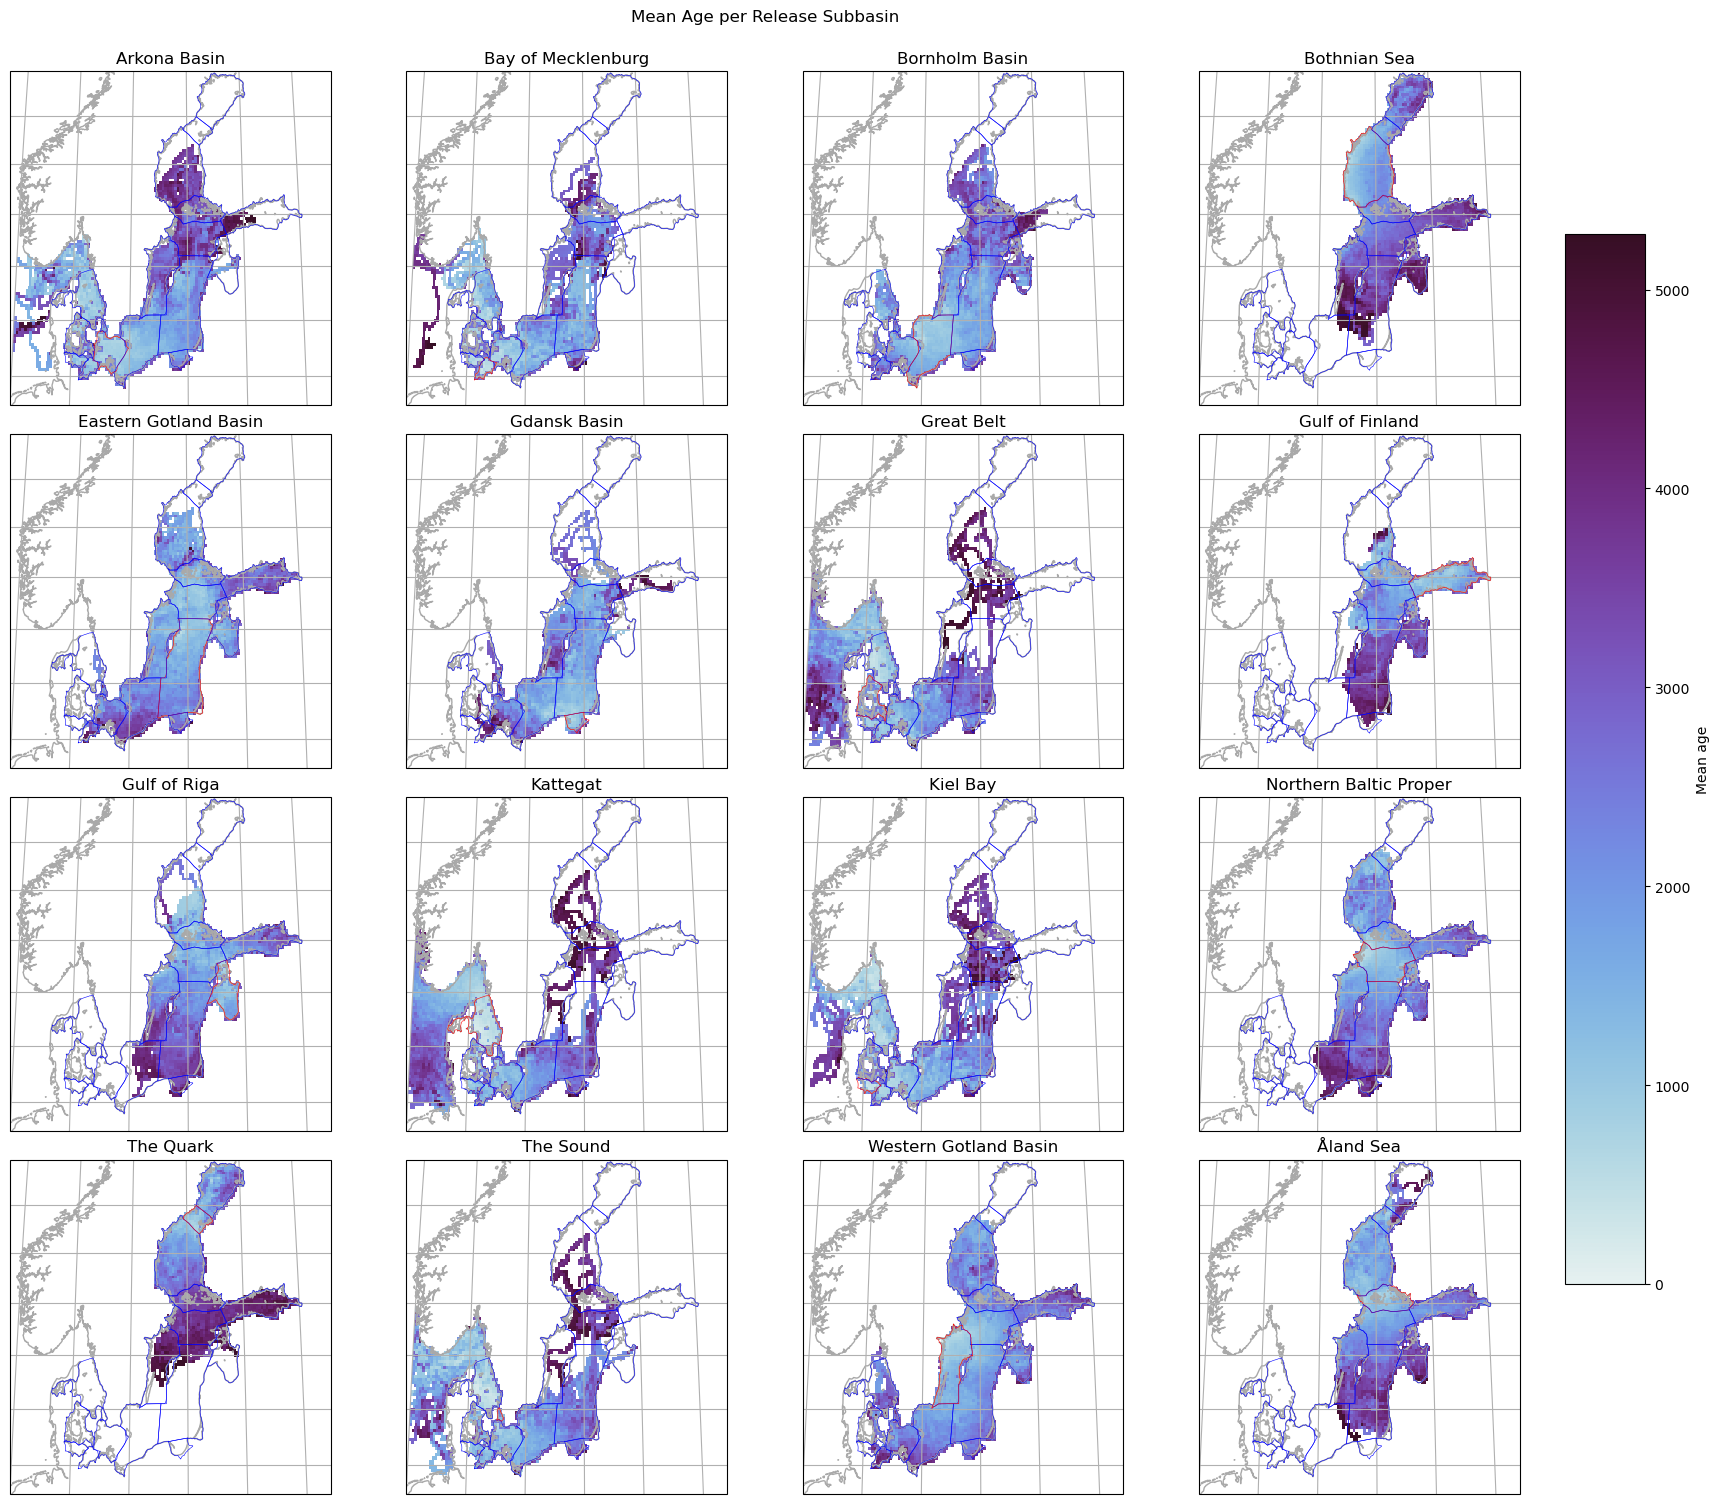

In [30]:
ds_plot = ds_plot_traj_age
vmax = ds_plot.max()
norm = mpl.colors.Normalize(0,vmax)
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, 
        ncols=4, 
        sharex=True, 
        sharey=True, 
        subplot_kw=dict(projection=map_projection), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot.subbasin.values):
        color = np.where(subbasins_simple.index == basin, "r", "b")
        subbasins_simple.plot(ax=ax, transform=Geodetic(), color=color, lw=.4, zorder=10)
        im = ds_plot.sel(subbasin=basin).plot.pcolormesh(
                x="lon", 
                y="lat", 
                ax=ax, 
                cmap=cmocean.cm.dense,
                norm=norm, 
                add_colorbar=False,
                transform=PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent(extent)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Mean age")
fig.tight_layout()
plt.show()

## Animations

In [24]:
import matplotlib.animation as animation

In [25]:
max_age = timedelta(seconds=int(last_step.age_sec.max()))
max_age_days = int(np.ceil(max_age.days))

In [ ]:
ds_ani = ds_plot_traj_count.sel(subbasin="Kiel Bay").groupby_bins(group="obs", bins=max_age_days).mean(dim="obs").rename(dict(obs_bins="obs"))

# vmin, vmax = list(ds_plot.where(ds_plot.notnull() & ds_plot > 0).quantile([0.05, 0.95]))
vmax = ds_ani.where(ds_ani.notnull() & (ds_ani > 0)).quantile(0.95)
norm = LogNorm(vmin=1, vmax=vmax)
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(projection=ccrs.PlateCarree()), 
)
heat = ax.pcolormesh(
        ds_ani.lon, ds_ani.lat,
        ds_ani.isel(obs=0).T,
        norm=norm,
        transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
def animate(i):
        heat.set_array(ds_ani.isel(obs=i).values.T.flatten())

ani = animation.FuncAnimation(
        fig, animate, 
        interval=100, frames=len(ds_ani.obs)
)
ani.save(
        filename=str(repo_path / "output/kiel_bay_heatmap.gif"), 
        writer="pillow")
plt.show()

# Coastbuffer
Make coast buffer for check if near coast or in open water

In [22]:
gdf_baltic = gdf_subbasins_area.dissolve()
coast_region_radius_km = 25
coast_region_radius = coast_region_radius_km / earth_radius * radians_to_degrees
gdf_baltic_simple = gdf_baltic.buffer(.1).buffer(-.1)
# gdf_baltic_benthic = gdf_baltic_simple.buffer(-coast_region_radius)
# gdf_baltic_coast = gdf_baltic_buffed.difference(gdf_baltic_benthic)
# gdf_baltic_coast

In [ ]:
gdf_baltic_coast = gdf_baltic_simple.boundary.buffer(.2)

<Axes: >

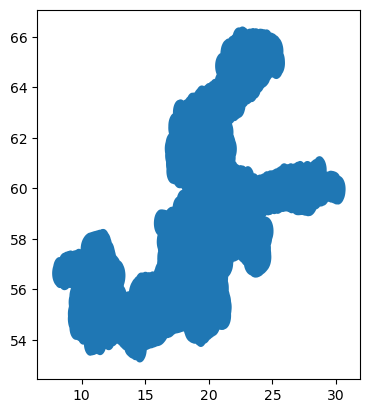

In [155]:
gdf_baltic_simple.buffer(.5).plot()

<Axes: >

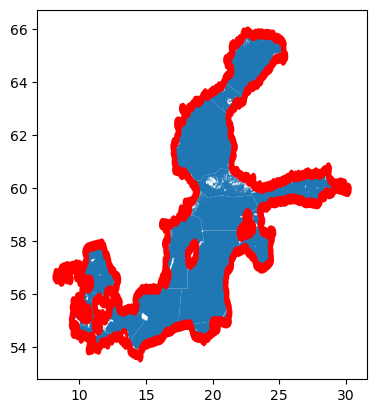

In [24]:
fig, ax = plt.subplots()
gdf_subbasins_area.plot(ax=ax)
gdf_baltic_coast.plot(ax=ax, color="r")

<Axes: >

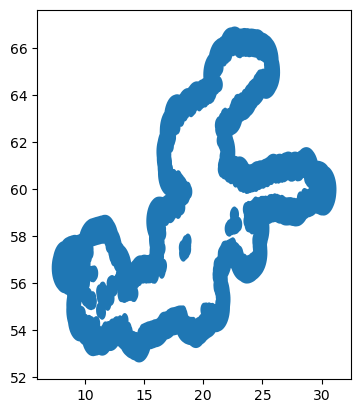

In [185]:
gdf_baltic_coast_extended = gdf_baltic_simple.buffer(1).difference(gdf_baltic_simple).union(gdf_baltic_coast)
gdf_baltic_coast_extended.plot()

In [188]:
gdf_first_step["near_coast"] = gdf_first_step.within(gdf_baltic_coast_extended.unary_union)

gdf_first_step = gpd.sjoin_nearest(
        left_df=gdf_first_step,
        right_df=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

In [189]:
df_last_step = last_step[["lon", "lat"]].drop("obs").to_dataframe()
gdf_last_step = gpd.GeoDataFrame(
        dict(
                trajectory=last_step.trajectory,
                geometry=gpd.points_from_xy(df_last_step.lon, df_last_step.lat),
        ),
        crs=gdf_baltic_coast.crs,
)
gdf_last_step = gdf_last_step.loc[:10000]

<Axes: >

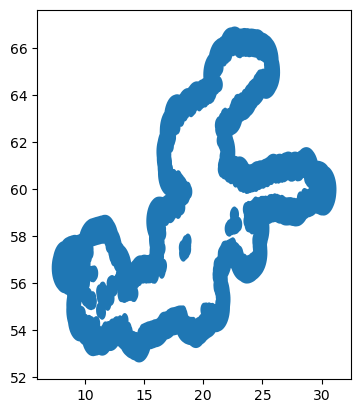

In [200]:
gdf_baltic_coast_extended.plot()

In [190]:
gdf_last_step["near_coast"] = gdf_last_step.within(gdf_baltic_coast_extended.unary_union)
gdf_last_step = gdf_last_step.sjoin_nearest(
        right=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

In [ ]:
gdf_joined = gdf_first_step.join(gdf_last_step, on="trajectory", how="right", lsuffix="_first", rsuffix="_last")

In [ ]:
gdf_joined["stayed_in_basin"] = (gdf_joined.subbasin_last == gdf_joined.subbasin_first)
gdf_joined["stayed_near_coast"] = (gdf_joined.near_coast_last & gdf_joined.near_coast_first) == True
gdf_joined["stayed_local"] = gdf_joined.stayed_in_basin & gdf_joined.stayed_near_coast

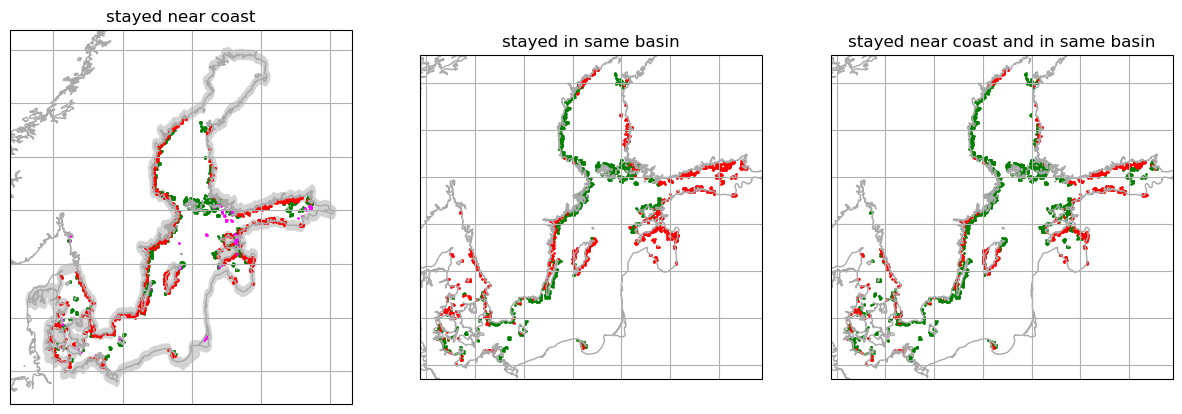

In [201]:
fig, axes = plt.subplots(figsize=(15,5), ncols=3, subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = axes.flatten()
gdf_baltic_coast.plot(ax=axes[0], color="lightgrey")
gdf_joined.where(gdf_joined.stayed_near_coast != True).dropna().geometry_first.plot(ax=axes[0], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_near_coast == True).dropna().geometry_first.plot(ax=axes[0], markersize=1, color="r")
gdf_joined.where(gdf_joined.near_coast_last != True).dropna().geometry_last.plot(ax=axes[0], markersize=1, color="magenta")
axes[0].set_title("stayed near coast")
gdf_joined.where(gdf_joined.stayed_in_basin != True).dropna().geometry_first.plot(ax=axes[1], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_in_basin == True).dropna().geometry_first.plot(ax=axes[1], markersize=1, color="r")
axes[1].set_title("stayed in same basin")
gdf_joined.where(gdf_joined.stayed_local != True).dropna().geometry_first.plot(ax=axes[2], markersize=1, color="g")
gdf_joined.where(gdf_joined.stayed_local == True).dropna().geometry_first.plot(ax=axes[2], markersize=1, color="r")
axes[2].set_title("stayed near coast and in same basin")
for ax in axes:
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
plt.show()

In [ ]:
gdf_first_step["near_coast"] = gdf_first_step.within(gdf_baltic_coast.unary_union)

gdf_first_step = gpd.sjoin_nearest(
        left_df=gdf_first_step,
        right_df=gdf_subbasins_area,
        how="left", 
        rsuffix="basin_",
)[["trajectory", "geometry", "near_coast", "subbasin"]]

statistics of in which month and from which starting position do the particles travel how far, and the area

In [10]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [ ]:
def calc_dist_mean(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).mean(dim="trajectory").rename("dist")

In [12]:
df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()

KeyError: "No variable named 'subbasin'. Variables on the dataset include ['age_sec', 'cell_ID', 'lat', 'lon', 'obs', 'time', 'trajectory', 'z']"

In [ ]:
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [ ]:
df_distance_m = ds_trajectories.groupby("subbasin").apply(calc_dist_mean).compute().to_dataframe()
df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(len(ds_trajectories.obs))).set_index("time", drop=True).resample("5D").mean()["dist"]

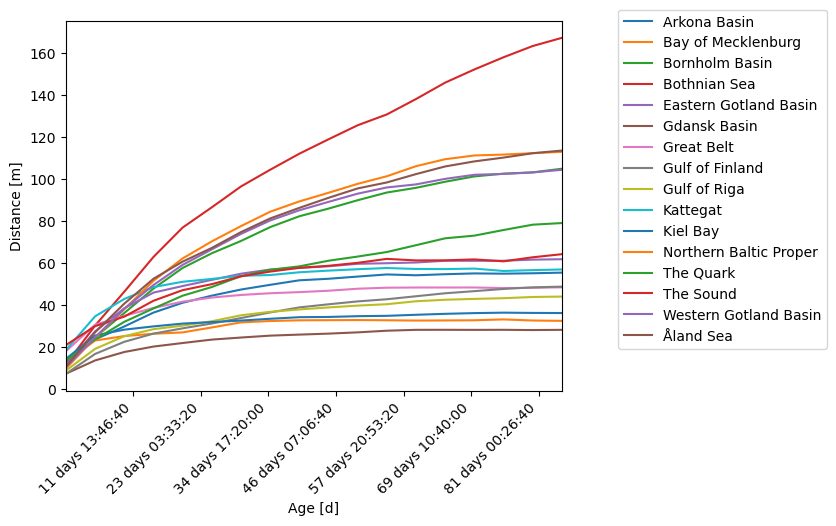

In [252]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_traj_0_5d.distance.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

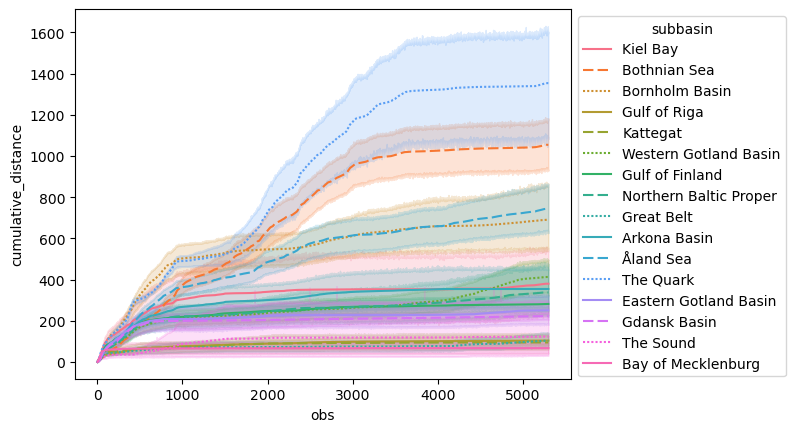

In [ ]:
fig = plt.Figure((15,15))
ax = sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

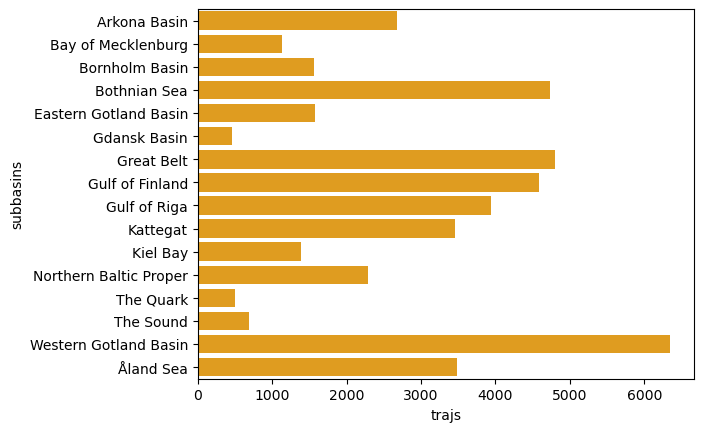

<Axes: xlabel='cells', ylabel='subbasins'>

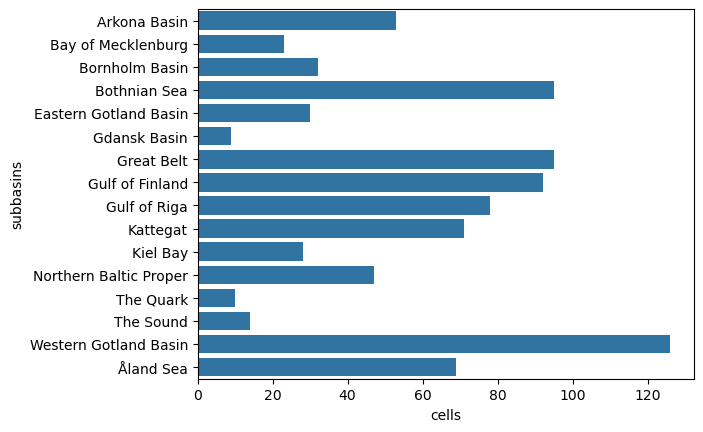

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")